In [1]:
from typing import TypedDict, List, Optional, Dict, Union, Any, Annotated, Sequence
from dotenv import load_dotenv  
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
import httpx
import os

In [2]:
load_dotenv()

True

In [3]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]

In [4]:
@tool
def fetch_weather(city):
  """Fetches the weather of different cities."""
  url = "http://api.weatherapi.com/v1/current.json"

  params = {
    "key": os.getenv("weather_api_key"),
    "q": city
  }
  try:
    response = httpx.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    return {
      "city": data["location"]["name"],
      "country": data["location"]["country"],
      "temp": data["current"]["temp_c"],
      "condition": data["current"]["condition"]["text"]
    }
  except httpx.RequestError as e:
    print(f"Request Error: {e}")


In [5]:
tools = [fetch_weather]

In [6]:
llm = ChatGroq(model="llama-3.3-70b-versatile").bind_tools(tools)

In [7]:
system_prompt = SystemMessage(content = "You are a helpful assistant.")

In [8]:
def llm_call(state: AgentState) -> AgentState:
    """Call the LLM with the current state and return the updated state."""
    response = llm.invoke([system_prompt] + state["messages"])
    
    return {"messages": [response]}

In [9]:
# def should_continue(state: AgentState): 
#     messages = state["messages"]
#     last_message = messages[-1]
#     if not last_message.tool_calls: 
#         return "end"
#     else:
#         return "continue"

In [10]:
graph = StateGraph(AgentState)

graph.add_node("agent", llm_call)
tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.add_edge(START, "agent")
graph.add_edge("agent", "tools")
graph.add_edge("tools", END)

app = graph.compile()

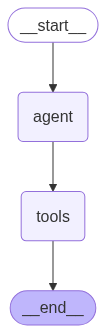

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

query = input("Enter your Escape.....")
inputs = {"messages": [("user", query)]}

print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

I wanna travel to edinburgh this weekend. What's the climate there??
================================== Ai Message ==================================
Tool Calls:
  fetch_weather (yqp4say3c)
 Call ID: yqp4say3c
  Args:
    city: Edinburgh
================================= Tool Message =================================
Name: fetch_weather

{"city": "Edinburgh", "country": "United Kingdom", "temp": 12.1, "condition": "Partly Cloudy"}
